## Assignment Dataset — student_performance.csv



### **Part A — Load, Inspect & Explore**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
import os
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

uploaded = files.upload()
pd.set_option('display.max_columns', 30)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

df = pd.read_csv("/content/student_performance - student_performance.csv")


Saving student_performance - student_performance.csv to student_performance - student_performance.csv


# Q1.  Read student_performance.csv into a DataFrame called df. Then:
(a) Print the number of rows and columns.

(b) Show the first 5 rows.

(c) Print each column's data type and identify which columns have missing values and how many

In [36]:
print("Rows and Columns:", df.shape)

Rows and Columns: (80, 14)


In [3]:
df.head()

,student_id,gender,department,year_of_study,home_city,cgpa,study_hours_per_week,attendance_percent,participates_in_clubs,sleep_hours_per_night,tuition_fee,scholarship,final_grade,letter_grade
0,A200,Male,Architecture,1,Sylhet,3.61,16.60,85.50,Yes,7.90,35000,NaN,81,A+
1,A201,Female,EEE,1,Chittagong,3.32,16.20,75.50,Yes,5.50,30000,Partial,92,A+
2,A202,Male,Pharmacy,1,Sylhet,3.29,9.50,61.90,No,7.30,35000,Partial,74,A-
3,A203,Male,Pharmacy,4,Mymensingh,3.38,15.90,67.80,No,6.70,30000,NaN,91,A+
4,A204,Male,Architecture,1,Dhaka,3.50,13.40,98.60,Yes,5.40,35000,Partial,96,A+


In [4]:
df.info()

print("\nMissing values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             80 non-null     object 
 1   gender                 80 non-null     object 
 2   department             80 non-null     object 
 3   year_of_study          80 non-null     int64  
 4   home_city              80 non-null     object 
 5   cgpa                   76 non-null     float64
 6   study_hours_per_week   74 non-null     float64
 7   attendance_percent     75 non-null     float64
 8   participates_in_clubs  80 non-null     object 
 9   sleep_hours_per_night  77 non-null     float64
 10  tuition_fee            80 non-null     int64  
 11  scholarship            38 non-null     object 
 12  final_grade            80 non-null     int64  
 13  letter_grade           80 non-null     object 
dtypes: float64(4), int64(3), object(7)
memory usage: 8.9+ KB

Mi

# Q2.  Extract the final_grade and cgpa columns as NumPy arrays. Using NumPy only (not pandas methods), compute:
(a) Mean, maximum, and minimum of final_grade.

(b) Mean of cgpa ignoring missing values.

(c) The Pearson correlation coefficient between final_grade and cgpa (drop rows where either is NaN first)

In [5]:
final_Grade = df["final_grade"].to_numpy()
print("Final Grade Mean - ",np.mean(final_Grade))
print("Final Grade Max - ",np.max(final_Grade))
print("Final Grade Min - ",np.min(final_Grade))

Final Grade Mean -  80.6
Final Grade Max -  100
Final Grade Min -  55


In [6]:
cgpa = df["cgpa"].to_numpy()

print("Mean CGPA ignoring missing value:", np.nanmean(cgpa))

Mean CGPA ignoring missing value: 3.031184210526316


In [7]:
data = df[["final_grade", "cgpa"]].dropna()

correlation = data["final_grade"].corr(data["cgpa"])

print("Pearson correlation:", correlation)

Pearson correlation: 0.6063193417625353


## Q3.  Use DataFrame selection to answer each sub-question:
(a) Select rows 10–19 and the columns in positions 2, 3, 4, and 12.

(b) Show the student_id, department, cgpa, and final_grade columns for the first 8 students.

(c) Show all CSE students in Year 3 or 4 who have attendance_percent > 80.

(d) Count how many students do not have a scholarship and scored final_grade < 60

In [8]:
print(df.iloc[10:20,[2,3,4,12]])

      department  year_of_study   home_city  final_grade
10           EEE              2       Dhaka           85
11           CSE              4      Sylhet           72
12           CSE              2       Dhaka           65
13           CSE              2  Chittagong           84
14  Architecture              3  Mymensingh           88
15           EEE              1       Dhaka           56
16           CSE              3    Rajshahi           83
17           EEE              2  Chittagong           65
18           CSE              1       Dhaka           76
19           CSE              3       Dhaka           90


In [9]:
print(df.loc[:8,["student_id","department","cgpa","final_grade"]])

  student_id    department  cgpa  final_grade
0       A200  Architecture  3.61           81
1       A201           EEE  3.32           92
2       A202      Pharmacy  3.29           74
3       A203      Pharmacy  3.38           91
4       A204  Architecture  3.50           96
5       A205           CSE  2.01           55
6       A206           CSE   NaN          100
7       A207  Architecture  2.37           72
8       A208           BBA  3.77           91


In [10]:
cse_student = df[(df["department"] == "CSE") & (df["year_of_study"].isin([3, 4])) & (df["attendance_percent"] > 80)]

print("CSE students with attendance above 80% \n", cse_student)


CSE students with attendance above 80% 
    student_id  gender department  year_of_study home_city  cgpa  \
9        A209    Male        CSE              4     Dhaka  2.58   
11       A211  Female        CSE              4    Sylhet  2.57   
16       A216    Male        CSE              3  Rajshahi  3.18   
50       A250  Female        CSE              4    Sylhet  2.46   
52       A252    Male        CSE              3     Dhaka  3.26   
61       A261    Male        CSE              3     Dhaka  3.97   
71       A271    Male        CSE              4    Khulna  2.71   

    study_hours_per_week  attendance_percent participates_in_clubs  \
9                  17.60               90.60                   Yes   
11                  9.90               81.90                   Yes   
16                 19.20               97.30                    No   
50                 19.30               83.20                    No   
52                  5.90              100.00                   Yes   
61

In [11]:
no_Scholarship = df[(df["scholarship"].isna()) & (df["final_grade"]<60)]

print("\nNo Scholarship student:\n", no_Scholarship)
print("\n\nNo Scholarship student:", len(no_Scholarship))


No Scholarship student:
    student_id  gender department  year_of_study   home_city  cgpa  \
5        A205  Female        CSE              1  Mymensingh  2.01   
15       A215    Male        EEE              1       Dhaka  2.35   

    study_hours_per_week  attendance_percent participates_in_clubs  \
5                   5.20               80.60                    No   
15                 10.50               52.50                   Yes   

    sleep_hours_per_night  tuition_fee scholarship  final_grade letter_grade  
5                    6.50        35000         NaN           55           B-  
15                   5.50        30000         NaN           56           B-  


No Scholarship student: 2


## Q4.  Explore the data with aggregation and visualisation:
(a) Find the average final_grade and average attendance_percent per department, sorted by average final_grade descending.

(b) Count students by scholarship type and by year_of_study. Which year has the most students?

(c) Draw a bar chart of the average final_grade per department, and a histogram of final_grade with 15 bins.

(d) State two findings from your EDA in plain English (e.g. which department scores highest, how attendance relates to grades).

In [12]:
avg_grade_atten = df.groupby("department")[["final_grade","attendance_percent"]].mean()

avg_grade_atten = avg_grade_atten.sort_values(
    by = "final_grade", ascending = False
)

print("Average final grade and attendance per department:\n",avg_grade_atten)


Average final grade and attendance per department:
               final_grade  attendance_percent
department                                   
Architecture        81.36               84.34
Pharmacy            80.93               76.41
CSE                 80.80               82.95
EEE                 80.27               77.04
BBA                 79.33               73.45


In [13]:
student_Scho = df["scholarship"].value_counts(dropna=False)
print("Scholarship student are:\n", student_Scho)

most_students_year = df["year_of_study"].value_counts().idxmax()

print("Year with most students:", most_students_year)

Scholarship student are:
 scholarship
NaN        42
Partial    31
Full        7
Name: count, dtype: int64
Year with most students: 1


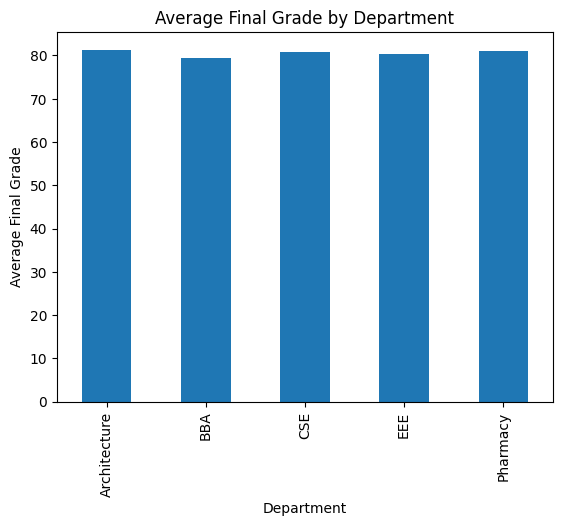

In [14]:
avg_grade = df.groupby("department")["final_grade"].mean()

avg_grade.plot(kind="bar")

plt.xlabel("Department")
plt.ylabel("Average Final Grade")
plt.title("Average Final Grade by Department")
plt.show()

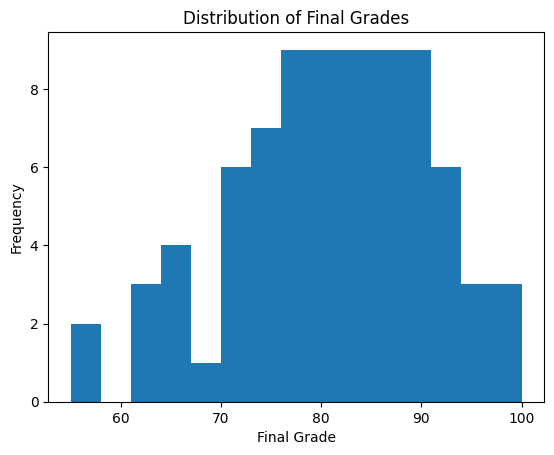

In [15]:
df["final_grade"].plot(
    kind="hist",
    bins=15,
    title="Distribution of Final Grades"
)

plt.xlabel("Final Grade")
plt.show()

In [16]:
dept_avg = df.groupby("department")["final_grade"].mean()

print("Average final grade by department:")
print(dept_avg)

print("\nDepartment with highest average grade:")
print(dept_avg.idxmax())

correlation = df["attendance_percent"].corr(df["final_grade"])

print("Correlation between attendance and final grade:", correlation)

print("Finding 1:")
print(f"{dept_avg.idxmax()} has the highest average final grade.")

print("\nFinding 2:")
if correlation > 0:
    print("Higher attendance generally relates to higher final grades.")
elif correlation < 0:
    print("Higher attendance generally relates to lower final grades.")
else:
    print("Attendance has little or no relationship with final grades.")

Average final grade by department:
department
Architecture   81.36
BBA            79.33
CSE            80.80
EEE            80.27
Pharmacy       80.93
Name: final_grade, dtype: float64

Department with highest average grade:
Architecture
Correlation between attendance and final grade: 0.34396610039891357
Finding 1:
Architecture has the highest average final grade.

Finding 2:
Higher attendance generally relates to higher final grades.


# **1. The Architecture department has the highest average final_grade.**

# **2.  From the code above we can see that, Students with higher attendance generally tend to have higher final grades, indicating a positive relationship between attendance and academic performance.**

### **Part B — Data Preprocessing**

## Q5.  Before any preprocessing, split the data. Use final_grade as the target (y) and all other columns except student_id and letter_grade as features (X).

(a) Create X_train, X_test, y_train, y_test with a 75/25 split and random_state=42.

(b) Print the size of each split and confirm the shapes are as expected.

(c) Explain in a comment why you must split BEFORE any imputation or scaling — what goes wrong if you don't?

In [17]:
X = df.drop(columns=["student_id", "letter_grade", "final_grade"])
y = df["final_grade"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (80, 11)
y shape: (80,)


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)


In [19]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (60, 11)
X_test: (20, 11)
y_train: (60,)
y_test: (20,)


### **We must split the data before imputation or scaling to prevent data leakage. If we preprocess the entire dataset first, information from the test set can influence the preprocessing. This makes the model evaluation unfair.**

## Q6.  Impute missing values in the training set, then apply the same imputer to the test set.
(a) For the numeric columns with missing values (cgpa, study_hours_per_week, attendance_percent, sleep_hours_per_night), use SimpleImpute (strategy='median').

(b) Fit the imputer on X_train only. Transform both X_train and X_test.

(c) Confirm that neither split has missing values after imputation.

(d) Why is the median preferred over the mean for imputation? Give one reason.

In [20]:
numeric_cols = ["cgpa","study_hours_per_week","attendance_percent","sleep_hours_per_night"]

imputer = SimpleImputer(strategy="median")



In [21]:
X_train[numeric_cols] = imputer.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = imputer.transform(X_test[numeric_cols])

In [22]:
print("Missing values in X_train:")
print(X_train.isnull().sum())

print("\nMissing values in X_test:")
print(X_test.isnull().sum())

Missing values in X_train:
gender                    0
department                0
year_of_study             0
home_city                 0
cgpa                      0
study_hours_per_week      0
attendance_percent        0
participates_in_clubs     0
sleep_hours_per_night     0
tuition_fee               0
scholarship              31
dtype: int64

Missing values in X_test:
gender                    0
department                0
year_of_study             0
home_city                 0
cgpa                      0
study_hours_per_week      0
attendance_percent        0
participates_in_clubs     0
sleep_hours_per_night     0
tuition_fee               0
scholarship              11
dtype: int64


### **If there are outliers, the mean can give a misleading value, while the median is usually more reliable.**

## Q7. The categorical columns must be converted to numbers before modelling.
(a) Apply OneHotEncoder(drop=&#39;first&#39;, sparse_output=False) to gender, department, home_city,scholarship. Fit on train, transform both splits.

(b) Encode participates_in_clubs as a binary column (Yes → 1, No → 0).

(c) Why do we use drop=&#39;first&#39; in the OneHotEncoder? What problem does it prevent?

In [23]:
categorical_cols = ["gender","department","home_city","scholarship"]
encoder = OneHotEncoder(drop="first",sparse_output=False)

X_train_encoded = encoder.fit_transform(X_train[categorical_cols])
X_test_encoded = encoder.transform(X_test[categorical_cols])

print(X_test_encoded)

[[1. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1.]
 [0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1.]
 [1. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0.]
 [1. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 1. 0.]
 [1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0.]
 [1. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 1. 0.]
 [1. 0. 0. 0. 1. 0. 1. 0. 0. 0. 1. 0.]
 [1. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 1.]
 [0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 1.]
 [1. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0.]
 [1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1.]]


In [24]:
X_train["participates_in_clubs"] = X_train["participates_in_clubs"].map({"Yes": 1, "No": 0})
X_test["participates_in_clubs"] = X_test["participates_in_clubs"].map({"Yes": 1, "No": 0})

print(X_test["participates_in_clubs"])

30    0
0     1
22    1
31    0
18    1
28    1
10    1
70    0
4     1
12    0
49    0
33    0
67    1
35    0
68    1
45    1
73    0
61    1
55    0
40    0
Name: participates_in_clubs, dtype: int64


### **drop='first' removes one category from each categorical variable to prevent redundant information and dummy variable trap.**

## Q8. Scale the numeric features so that distance-based models (KNN, neural networks) are not dominated by large-valued columns.
(a) Apply StandardScaler() to the numeric feature columns (year_of_study, cgpa,
study_hours_per_week, attendance_percent, sleep_hours_per_night, tuition_fee).

(b) Fit on X_train only. Transform both splits.

(c) Verify that the scaled training data has mean ≈ 0 and std ≈ 1. Print both.

(d) Give one example of a model that does not need scaling, and explain why.

In [25]:
numeric_features = ["year_of_study","cgpa","study_hours_per_week","attendance_percent","sleep_hours_per_night","tuition_fee"]

scaler = StandardScaler()

X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

In [26]:
print("Mean:\n", X_train[numeric_features].mean())
print("\nStandard Deviation:\n", X_train[numeric_features].std())


Mean:
 year_of_study           -0.00
cgpa                    -0.00
study_hours_per_week    -0.00
attendance_percent      -0.00
sleep_hours_per_night    0.00
tuition_fee             -0.00
dtype: float64

Standard Deviation:
 year_of_study           1.01
cgpa                    1.01
study_hours_per_week    1.01
attendance_percent      1.01
sleep_hours_per_night   1.01
tuition_fee             1.01
dtype: float64


### **Decision Tree does not need scaling because it makes decisions using conditions/splits on individual features, not distances or feature magnitudes.**

## Q9. Combine everything into a single Pipeline using ColumnTransformer so that all steps happen automatically and leak-proof.

(a) Build a ColumnTransformer that applies SimpleImputer + StandardScaler to the four numeric columnswith missing values, and OneHotEncoder to the categorical columns.

(b) Wrap the ColumnTransformer in a Pipeline. Fit it on X_train and transform both X_train and X_test.

(c) Print the shape of the transformed training and test matrices.

(d) Explain in a comment why putting transformers inside a Pipeline is safer than applying them step by step.

In [27]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(drop="first", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("cat", categorical_pipeline, categorical_cols)
])



In [28]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [29]:
print("X_train_processed shape:", X_train_processed.shape)
print("X_test_processed shape:", X_test_processed.shape)

X_train_processed shape: (60, 15)
X_test_processed shape: (20, 15)


In [30]:
# For showing the transfrom colum
X_train_df = pd.DataFrame(
    X_train_processed,
    columns=preprocessor.get_feature_names_out()
)

print(X_train_df.head(3))

   num__cgpa  num__study_hours_per_week  num__attendance_percent  \
0      -0.76                       1.00                     1.03   
1      -0.92                       0.43                     0.18   
2      -1.77                      -2.05                     0.22   

   num__sleep_hours_per_night  cat__gender_Male  cat__department_BBA  \
0                       -1.79              1.00                 0.00   
1                        0.43              1.00                 1.00   
2                       -0.15              0.00                 0.00   

   cat__department_CSE  cat__department_EEE  cat__department_Pharmacy  \
0                 1.00                 0.00                      0.00   
1                 0.00                 0.00                      0.00   
2                 1.00                 0.00                      0.00   

   cat__home_city_Dhaka  cat__home_city_Khulna  cat__home_city_Mymensingh  \
0                  1.00                   0.00                      

## **Pipeline is safer because it keeps all preprocessing steps together and applies them consistently, reducing the risk of data leakage.**

# Q10. Add the following two columns to the original (un-split) DataFrame, then report an insight:
(a) study_load = &quot;Heavy&quot; if study_hours_per_week &gt;= 15, else &quot;Light&quot; (use np.where).

(b) grade_band = &quot;High&quot; if final_grade &gt;= 70, &quot;Mid&quot; if 50 &lt;= final_grade &lt; 70, &quot;Low&quot; otherwise (use np.select or chained np.where).

(c) Show the count of students in each grade_band and the average final_grade for Heavy vs Light study-load students. State whether the difference is meaningful.

In [31]:
df["study load"] = np.where(df["study_hours_per_week"] >=15 ,"Heavy","Light")

print(df[["study load","study_hours_per_week"]])

   study load  study_hours_per_week
0       Heavy                 16.60
1       Heavy                 16.20
2       Light                  9.50
3       Heavy                 15.90
4       Light                 13.40
..        ...                   ...
75      Light                  8.30
76      Light                   NaN
77      Light                 14.10
78      Heavy                 17.20
79      Light                   NaN

[80 rows x 2 columns]


In [32]:
df["grade_band"] = np.select([df["final_grade"] >= 70,df["final_grade"].between(50, 70, inclusive="left")],
    ["High","Mid"],default="Low")

print(df[["grade_band","final_grade"]])



   grade_band  final_grade
0        High           81
1        High           92
2        High           74
3        High           91
4        High           96
..        ...          ...
75        Mid           61
76       High           83
77       High           77
78       High           86
79       High           80

[80 rows x 2 columns]


In [33]:
print(df["grade_band"].value_counts())

print(df.groupby("study load")["final_grade"].mean())

grade_band
High    70
Mid     10
Name: count, dtype: int64
study load
Heavy   83.75
Light   78.90
Name: final_grade, dtype: float64


# Q11. The code below contains a data leakage bug. Identify it, explain why it is wrong, and write the corrected version.
# --- buggy code ---
scaler = StandardScaler()

X_all_scaled = scaler.fit_transform(X) # fit on ALL data

X_train_s = X_all_scaled[train_idx]

X_test_s = X_all_scaled[test_idx]

(a) Which single line causes the leakage and why?

(b) Rewrite the block correctly (3–4 lines).

(c) What inflated or misleading result could this bug produce in a real project?

# **X_all_scaled = scaler.fit_transform(X)**

Because the scaler is being fitted on ALL data, including the test data.

ALL DATA = Training data  +  Test data

Test data should be kept separate

# When fit_transform(X) runs, the scaler learns the mean and standard deviation from both training and test data. So the test data is indirectly influencing the training preprocessing.

This is called data leakage.


# **scaler = StandardScaler()**
# **X_train_s = scaler.fit_transform(X_train)**
# **X_test_s = scaler.transform(X_test)**

### **Fit the scaler only on training data, then use the same scaling rules to transform both training and test data, preventing data leakage.**


## **It is like getting some information about the test questions before an exam. You may get a higher score, but the result does not show your model's real performance.**

# Q12. Write a short summary (in a Markdown cell) and a compact code block that demonstrates the complete, correct Week 04 preprocessing workflow for this dataset:
(a) In plain English, list each step of the preprocessing in order, stating what you do and why.

(b) Write a single code cell that recreates the full pipeline from scratch using Pipeline and ColumnTransformer, fits it on X_train, and prints the shape of both transformed splits.

(c) If a new student record arrived with two missing values and a new city not in the training data, what would happen when you call .transform()? How would you handle it?

# Split the data first into training and testing sets so that test data does not influence preprocessing. Separate the features and target. Use final_grade as the target and exclude student_id and letter_grade from the features.
# Handle missing numeric values using SimpleImputer(strategy="median").
# Scale numeric features using StandardScaler() so large-valued features do not dominate the model. Handle categorical missing values using the most frequent value. Encode categorical features using OneHotEncoder(drop="first") so categorical values become numerical columns. Combine all preprocessing steps using ColumnTransformer and Pipeline. Fit only on X_train and use the fitted pipeline to transform both X_train and X_test to prevent data leakage.

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

df = pd.read_csv("/content/student_performance - student_performance.csv")

# Features and target
X = df.drop(columns=["student_id", "letter_grade", "final_grade"])
y = df["final_grade"]

# Split before preprocessing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

# Columns
numeric_cols = [
    "cgpa",
    "study_hours_per_week",
    "attendance_percent",
    "sleep_hours_per_night"
]

categorical_cols = [
    "gender",
    "department",
    "home_city",
    "scholarship"
]

# Numeric preprocessing
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        drop="first",
        sparse_output=False,
        handle_unknown="ignore"
    ))
])

# Combine preprocessing
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

# Complete pipeline
pipeline = Pipeline([
    ("preprocessing", preprocessor)
])

# Fit only on training data
X_train_processed = pipeline.fit_transform(X_train)

# Transform test data using training information
X_test_processed = pipeline.transform(X_test)

# Print shapes
print("X_train_processed shape:", X_train_processed.shape)
print("X_test_processed shape:", X_test_processed.shape)

X_train_processed shape: (60, 15)
X_test_processed shape: (20, 15)


# **Missing values are replaced by the imputer's learned values. For a new unseen city, use handle_unknown="ignore" in OneHotEncoder so .transform() does not produce an error.**

In [35]:
OneHotEncoder(
    drop="first",
    sparse_output=False,
    handle_unknown="ignore"
)

OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)